In [5]:
import os
# move up from notebooks -> project root
os.chdir(os.path.join(os.getcwd(),os.pardir))
print("Working dir is now:", os.getcwd())

DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
OUTPUT_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/output/05_plotting_energy_grids"

PREPROCESSED_PATH = DATA_PATH + "/preprocessed/01_first_analysises"


# create output path if it does not exist
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

if not os.path.exists(PREPROCESSED_PATH):
    os.makedirs(PREPROCESSED_PATH)

%load_ext autoreload
%autoreload 2

Working dir is now: /Users/adrian/Documents/01_projects
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import scipy.io
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from src.utils.saving_and_finding_files import time_stamp_for_saving, get_latest_file_name_of_data
from src.plotting.energy_landscape import plot_energy_landscape_from_df


/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation/gnm_grid_results_2025-08-08_16-09-53.csv


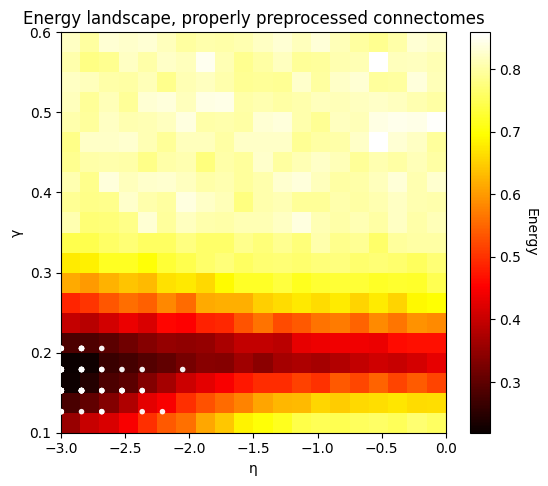

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': 'Energy landscape, properly preprocessed connectomes'}, xlabel='η', ylabel='γ'>)

In [8]:
# Plot heatmap of energy landscape from the latest GNM grid results
from src.plotting.energy_landscape import plot_energy_landscape_from_df

latest_gnm_grid_results_path, latest_gnm_grid_results_timestamp = get_latest_file_name_of_data("/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation", "gnm_grid_results_*.csv")
print(latest_gnm_grid_results_path)

df = pd.read_csv(latest_gnm_grid_results_path)

plot_energy_landscape_from_df(df, dot_color="white", 
                              title="Energy landscape, properly preprocessed connectomes", 
                              interpolation="nearest", 
                              savepath=OUTPUT_PATH + f"/energy_landscape_properly_preprocessed_connectomes_{latest_gnm_grid_results_timestamp}.png", 
                              show=True)


# Plotting other results

In [9]:
graph_measures_empirical_connectomes = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_bin.csv")
graph_measures_empirical_connectomes = graph_measures_empirical_connectomes.sort_values("network_index")
graph_measures_empirical_connectomes

,Unnamed: 0,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571
1,1,1,0.021016,0.559958,0.342192,0.552731,13.411765,0.457210,48.645978,2.046532,46,53.392462
2,2,2,0.021049,0.552275,0.418506,0.599042,13.411765,0.496317,47.508465,2.096576,47,60.049954
3,3,3,0.021261,0.556373,0.408566,0.570124,13.411765,0.469097,49.023596,2.069359,48,60.087251
4,4,4,0.020606,0.555897,0.336212,0.548212,13.411765,0.457649,48.363462,2.073749,52,52.655709
...,...,...,...,...,...,...,...,...,...,...,...,...
65,65,65,0.020709,0.559445,0.367106,0.566838,13.411765,0.469806,47.284030,2.049605,51,50.081903
66,66,66,0.020492,0.553995,0.402535,0.601771,13.411765,0.491271,46.985564,2.082529,51,57.814512
67,67,67,0.021370,0.558311,0.335142,0.558756,13.411765,0.469783,47.305744,2.056190,43,61.959989
68,68,68,0.021397,0.561509,0.342567,0.532443,13.411765,0.436678,47.695957,2.039508,44,52.333818


In [10]:
best_gnm_per_subject = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation/gnm_best_eval_2025-08-08_01-17-21.csv")
# order by "subject" 
best_gnm_per_subject = best_gnm_per_subject.sort_values("subject")
best_gnm_per_subject

,subject,eta,gamma,energy,memory_capacity,sequence_recall,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,-3.000000,0.152632,0.128535,"{'mc_mean': 1.0501359063453588, 'mc_std': 0.00...","{5: {'r2_mean': 0.9050766320488848, 'r2_std': ...",0,0.018427,0.449817,0.406341,0.492932,11.441176,0.518106,41.451730,2.200423,52,41.547116
2,1,-3.000000,0.152632,0.102941,"{'mc_mean': 1.052492757043535, 'mc_std': 0.008...","{5: {'r2_mean': 0.8860806592422724, 'r2_std': ...",0,0.020320,0.515108,0.320159,0.454020,13.411765,0.435115,44.085365,1.964286,52,46.990479
5,2,-3.000000,0.178947,0.161765,"{'mc_mean': 1.0457768440500357, 'mc_std': 0.00...","{5: {'r2_mean': 0.8179565798760826, 'r2_std': ...",0,0.018236,0.477941,0.327591,0.499860,13.411765,0.501518,43.938630,1.936066,64,45.236437
13,3,-2.526316,0.205263,0.117647,"{'mc_mean': 1.0507393745033984, 'mc_std': 0.00...","{5: {'r2_mean': 0.8350603511726995, 'r2_std': ...",0,0.015047,0.438181,0.356502,0.634753,13.411765,0.645413,53.053622,2.804067,79,51.892058
6,4,-3.000000,0.152632,0.116228,"{'mc_mean': 1.0494156553374387, 'mc_std': 0.00...","{5: {'r2_mean': 0.8909681954496451, 'r2_std': ...",0,0.019771,0.472271,0.286220,0.427677,13.411765,0.450562,44.145601,1.868362,53,44.930027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,65,-3.000000,0.178947,0.161765,"{'mc_mean': 1.043836054871625, 'mc_std': 0.008...","{5: {'r2_mean': 0.843930178605663, 'r2_std': 0...",0,0.018039,0.435323,0.329536,0.485098,13.411765,0.515810,44.390741,1.843985,53,45.772151
66,66,-2.684211,0.205263,0.205882,"{'mc_mean': 1.0506588348441106, 'mc_std': 0.00...","{5: {'r2_mean': 0.8543676420893476, 'r2_std': ...",0,0.015747,0.337723,0.243738,0.524349,13.411765,0.572891,50.423567,1.786348,67,52.170128
67,67,-3.000000,0.152632,0.147059,"{'mc_mean': 1.0527628733395888, 'mc_std': 0.00...","{5: {'r2_mean': 0.8795650026490268, 'r2_std': ...",0,0.020888,0.510243,0.394715,0.493931,13.411765,0.481542,41.481345,1.998016,49,46.221262
68,68,-2.684211,0.152632,0.132353,"{'mc_mean': 1.0471661732274986, 'mc_std': 0.00...","{5: {'r2_mean': 0.8702488675052287, 'r2_std': ...",0,0.018123,0.492135,0.300140,0.452666,13.411765,0.481221,46.210886,2.048643,65,45.809801


In [14]:
mean_r2_sr = {}

for subject in best_gnm_per_subject["sequence_recall"].values: 
    # turn the string into a dict
    subject = eval(subject)
    # print(subject)
    # print(subject.keys()) # dict keys 5,6,7,8,9,...,25 
    for key in subject.keys():
        if key not in mean_r2_sr:
            mean_r2_sr[key] = []
        mean_r2_sr[key].append(subject[key]["r2_mean"])

    # print(subject[5])
    # print(subject[5]["r2_mean"])

len(mean_r2_sr[5])

70

In [21]:
mean_r2_sr.keys()

dict_keys([5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25])

Text(0, 0.5, 'R2 mean')

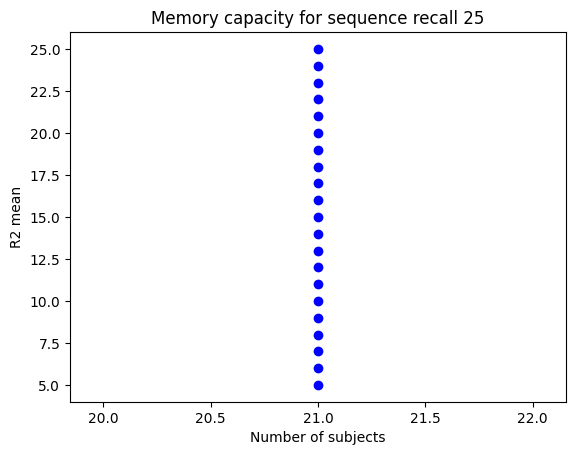

In [26]:
for i in mean_r2_sr.keys():
    # plt.figure(figsize=(10, 5))
    plt.scatter(len(mean_r2_sr), i, color="blue") # , label=str(i))
plt.title(f"Memory capacity for sequence recall {i}")
plt.xlabel("Number of subjects")
plt.ylabel("R2 mean")
# plt.savefig(OUTPUT_PATH + f"/memory_capacity_sequence_recall_{i}.png")    

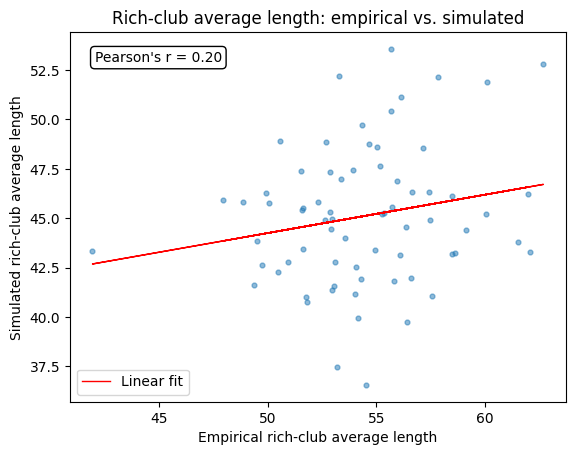

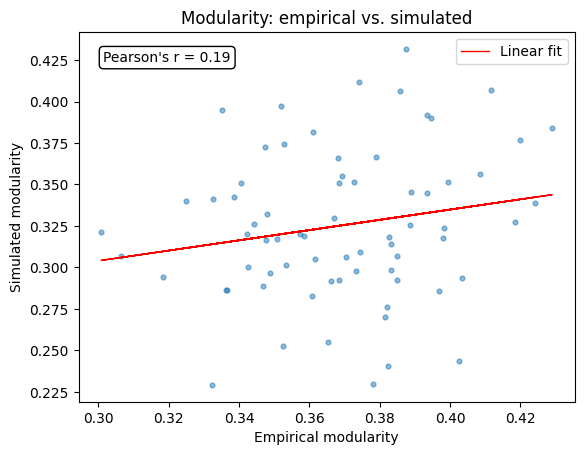

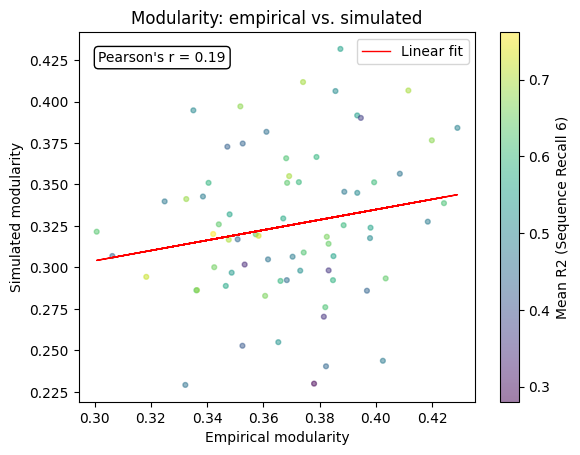

In [12]:
# variable_name = "richclub_avg_length"
from src.plotting.graphical_measures_measured_vs_simulated import plot_graph_measure_vs_simulated

variable_name = "richclub_avg_length"
plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name)

variable_name = "modularity"
plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name)

plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name, color_metric=mean_r2_sr[6], color_metric_name="Mean R2 (Sequence Recall 6)")
